# The Big Bang — Cinematic Educational Shorts Notebook

This is a **specific-event** notebook for one topic: **The Big Bang**.

It generates a more polished vertical info video with:

- procedural nebula / plasma backgrounds
- animated expansion particles
- cosmic inflation grid
- CMB-style first-light texture
- cosmic web + galaxy formation visuals
- glow typography, lower-third captions, progress bar, and scene transitions

**Outputs**

- `Big_Bang_Cinematic_Info_Shorts.mp4`
- `Big_Bang_Cinematic_Storyboard.png`

Run the cells from top to bottom. Start with `DRAFT_MODE = True` for a quick render, then switch it off for a sharper final export.

In [ ]:
# In a fresh Colab/Jupyter environment, uncomment this line:
# %pip install -U numpy pillow imageio imageio-ffmpeg tqdm

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import random
import textwrap
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import imageio.v2 as imageio

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

# ==========================
# Render settings
# ==========================
OUT_DIR = Path("big_bang_cinematic_output")
OUT_DIR.mkdir(exist_ok=True)

DRAFT_MODE = True  # True = faster preview. False = higher quality final render.

if DRAFT_MODE:
    W, H = 540, 960
    FPS = 20
else:
    W, H = 720, 1280
    FPS = 24

VIDEO_SECONDS = 42.0
NFRAMES = int(VIDEO_SECONDS * FPS)

VIDEO_NAME = OUT_DIR / "Big_Bang_Cinematic_Info_Shorts.mp4"
STORYBOARD_NAME = OUT_DIR / "Big_Bang_Cinematic_Storyboard.png"
SEED = 13
random.seed(SEED)
np.random.seed(SEED)

# ==========================
# Specific event script: The Big Bang
# ==========================
SCENES = [
    {
        "start": 0.0,
        "end": 6.2,
        "kind": "singularity",
        "eyebrow": "13.8 BILLION YEARS AGO",
        "title": "THE BIG BANG",
        "caption": "Not an explosion into space — the expansion of space itself.",
        "stat": "A hot, dense beginning",
    },
    {
        "start": 6.2,
        "end": 12.5,
        "kind": "inflation",
        "eyebrow": "FRACTIONS OF A SECOND",
        "title": "SPACE STRETCHES",
        "caption": "The early universe expanded incredibly fast, smoothing and enlarging everything.",
        "stat": "Cosmic inflation",
    },
    {
        "start": 12.5,
        "end": 19.4,
        "kind": "particle_soup",
        "eyebrow": "FIRST MINUTES",
        "title": "PARTICLE SOUP",
        "caption": "Energy cooled into particles, then simple atomic nuclei began to form.",
        "stat": "Quarks • electrons • photons",
    },
    {
        "start": 19.4,
        "end": 27.0,
        "kind": "first_light",
        "eyebrow": "380,000 YEARS LATER",
        "title": "FIRST LIGHT",
        "caption": "Atoms formed. Light could finally travel freely — we see it today as the cosmic microwave background.",
        "stat": "The universe becomes transparent",
    },
    {
        "start": 27.0,
        "end": 35.0,
        "kind": "cosmic_web",
        "eyebrow": "HUNDREDS OF MILLIONS OF YEARS",
        "title": "GRAVITY BUILDS STRUCTURE",
        "caption": "Tiny differences grew into a vast web of gas, dark matter, stars, and galaxies.",
        "stat": "From ripples to galaxies",
    },
    {
        "start": 35.0,
        "end": 42.0,
        "kind": "today",
        "eyebrow": "TODAY",
        "title": "THE EXPANSION CONTINUES",
        "caption": "The Big Bang is not just the beginning — it is the story of a universe still evolving.",
        "stat": "Look up. You are inside the evidence.",
    },
]

TITLE = "THE BIG BANG"
SUBTITLE = "A cinematic 42-second science short"

def scene_at(t: float) -> dict:
    for scene in SCENES:
        if scene["start"] <= t < scene["end"]:
            return scene
    return SCENES[-1]

def scene_local_t(scene: dict, t: float) -> float:
    return max(0.0, min(1.0, (t - scene["start"]) / (scene["end"] - scene["start"])))

In [2]:
# ==========================
# Fonts, easing, colors, text
# ==========================
def font_path(bold: bool = False) -> str | None:
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
        "/System/Library/Fonts/Supplemental/Arial Bold.ttf" if bold else "/System/Library/Fonts/Supplemental/Arial.ttf",
    ]
    for p in candidates:
        if p and Path(p).exists():
            return p
    return None

def load_font(size: int, bold: bool = False):
    p = font_path(bold)
    if p:
        return ImageFont.truetype(p, size)
    return ImageFont.load_default()

FONT_EYEBROW = load_font(max(16, W // 31), True)
FONT_TITLE = load_font(max(40, W // 8), True)
FONT_TITLE_SMALL = load_font(max(34, W // 11), True)
FONT_CAPTION = load_font(max(22, W // 24), False)
FONT_STAT = load_font(max(19, W // 29), True)
FONT_TINY = load_font(max(14, W // 42), False)

WHITE = (242, 246, 255)
CYAN = (120, 230, 255)
GOLD = (255, 202, 92)
ORANGE = (255, 117, 64)
PINK = (255, 98, 170)
VIOLET = (152, 122, 255)
BLACK = (4, 6, 14)

PALETTES = {
    "singularity": [(25, 6, 28), (255, 70, 37), (255, 219, 112), (255, 255, 245)],
    "inflation": [(4, 5, 22), (43, 86, 210), (120, 230, 255), (255, 255, 255)],
    "particle_soup": [(10, 5, 25), (122, 64, 255), (255, 98, 170), (255, 215, 95)],
    "first_light": [(20, 9, 4), (120, 50, 12), (255, 160, 65), (255, 231, 168)],
    "cosmic_web": [(2, 6, 18), (23, 55, 115), (120, 230, 255), (230, 248, 255)],
    "today": [(2, 5, 17), (31, 18, 65), (255, 202, 92), (255, 255, 245)],
}

def ease_in_out(x: float) -> float:
    x = max(0.0, min(1.0, x))
    return x * x * (3 - 2 * x)

def ease_out(x: float) -> float:
    x = max(0.0, min(1.0, x))
    return 1 - (1 - x) ** 3

def lerp(a, b, x):
    return a + (b - a) * x

def alpha_composite(base: Image.Image, overlay: Image.Image) -> Image.Image:
    if overlay.mode != "RGBA":
        overlay = overlay.convert("RGBA")
    base.alpha_composite(overlay)
    return base

def add_vignette(img: Image.Image, strength: float = 0.75) -> Image.Image:
    arr = np.array(img).astype(np.float32)
    yy, xx = np.mgrid[0:H, 0:W]
    cx, cy = W / 2, H / 2
    dist = np.sqrt(((xx - cx) / (W * 0.58)) ** 2 + ((yy - cy) / (H * 0.54)) ** 2)
    mask = np.clip(1 - strength * (dist ** 1.8), 0.15, 1.0)
    arr[..., :3] *= mask[..., None]
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8), "RGBA")

def glow_layer(size=(W, H), blur=18):
    return Image.new("RGBA", size, (0, 0, 0, 0))

def draw_glow_text(img: Image.Image, xy, text: str, font, fill=WHITE, anchor="mm", glow=(55, 180, 255), glow_radius=12, stroke=2):
    glow_img = Image.new("RGBA", img.size, (0, 0, 0, 0))
    gd = ImageDraw.Draw(glow_img)
    gd.text(xy, text, font=font, fill=glow + (180,), anchor=anchor, stroke_width=stroke, stroke_fill=glow + (100,))
    glow_img = glow_img.filter(ImageFilter.GaussianBlur(glow_radius))
    img.alpha_composite(glow_img)
    d = ImageDraw.Draw(img)
    d.text(xy, text, font=font, fill=fill + (255,), anchor=anchor, stroke_width=stroke, stroke_fill=(4, 8, 18, 220))


def text_size(text: str, font) -> tuple[int, int]:
    box = ImageDraw.Draw(Image.new("RGB", (1, 1))).textbbox((0, 0), text, font=font)
    return box[2] - box[0], box[3] - box[1]

def wrap_lines(text: str, font, max_width: int) -> list[str]:
    words = text.split()
    lines = []
    current = ""
    for word in words:
        test = (current + " " + word).strip()
        if text_size(test, font)[0] <= max_width:
            current = test
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return lines

def draw_panel_text(img: Image.Image, text: str, y: int, font, max_width=None, fill=WHITE, align="center", pad=22):
    max_width = max_width or int(W * 0.82)
    lines = wrap_lines(text, font, max_width)
    line_h = int(text_size("Ag", font)[1] * 1.55)
    box_h = len(lines) * line_h + pad * 2
    box_w = max(text_size(line, font)[0] for line in lines) + pad * 2
    x0 = (W - box_w) // 2
    y0 = y - box_h // 2
    panel = Image.new("RGBA", img.size, (0, 0, 0, 0))
    pd = ImageDraw.Draw(panel)
    pd.rounded_rectangle([x0, y0, x0 + box_w, y0 + box_h], radius=22, fill=(3, 8, 20, 155), outline=(140, 215, 255, 70), width=1)
    img.alpha_composite(panel)
    d = ImageDraw.Draw(img)
    for i, line in enumerate(lines):
        tw, _ = text_size(line, font)
        x = W // 2 - tw // 2 if align == "center" else x0 + pad
        d.text((x, y0 + pad + i * line_h), line, font=font, fill=fill + (245,))


def fitted_font(text: str, max_width: int, max_size: int, min_size: int = 24, bold: bool = True):
    """Return the largest font size that fits the requested width."""
    for size in range(max_size, min_size - 1, -2):
        f = load_font(size, bold)
        if text_size(text, f)[0] <= max_width:
            return f
    return load_font(min_size, bold)

def draw_glow_title(img: Image.Image, text: str, y: int, max_width: int):
    """Draw a title that automatically shrinks or wraps so it never clips."""
    single = fitted_font(text, max_width, max(34, W // 8), max(24, W // 16), True)
    if text_size(text, single)[0] <= max_width:
        draw_glow_text(img, (W//2, y), text, single, fill=WHITE, glow=(85, 205, 255), glow_radius=10, stroke=2)
        return

    # Wrap into two or three cinematic lines for long titles.
    line_font = fitted_font(text, max_width, max(30, W // 12), max(22, W // 18), True)
    lines = wrap_lines(text, line_font, max_width)
    if len(lines) > 3:
        # Last resort: split manually into balanced groups.
        words = text.split()
        midpoint = len(words) // 2
        lines = [" ".join(words[:midpoint]), " ".join(words[midpoint:])]
        line_font = fitted_font(max(lines, key=len), max_width, max(28, W // 13), max(20, W // 20), True)
    line_h = int(text_size("Ag", line_font)[1] * 1.15)
    start_y = y - (len(lines) - 1) * line_h // 2
    for i, line in enumerate(lines):
        draw_glow_text(img, (W//2, start_y + i * line_h), line, line_font, fill=WHITE, glow=(85, 205, 255), glow_radius=9, stroke=2)

def fade_edges(img: Image.Image, local: float, fade=0.10) -> Image.Image:
    # subtle black fade between scenes
    a = 0.0
    if local < fade:
        a = 1 - local / fade
    elif local > 1 - fade:
        a = (local - (1 - fade)) / fade
    if a <= 0:
        return img
    overlay = Image.new("RGBA", img.size, (0, 0, 0, int(155 * a)))
    img.alpha_composite(overlay)
    return img

In [3]:
# ==========================
# Deterministic procedural assets
# ==========================
rng = np.random.default_rng(SEED)

STAR_COUNT = 850 if not DRAFT_MODE else 520
STAR_X = rng.random(STAR_COUNT) * W
STAR_Y = rng.random(STAR_COUNT) * H
STAR_Z = rng.random(STAR_COUNT) * 1.0 + 0.2
STAR_SIZE = rng.random(STAR_COUNT) * 1.7 + 0.25
STAR_TWINKLE = rng.random(STAR_COUNT) * math.tau

PARTICLE_COUNT = 900 if not DRAFT_MODE else 600
ANGLES = rng.random(PARTICLE_COUNT) * math.tau
RADIAL = rng.random(PARTICLE_COUNT) ** 0.55
SPEED = rng.random(PARTICLE_COUNT) * 1.5 + 0.35
PARTICLE_COLOR_PICK = rng.integers(0, 4, PARTICLE_COUNT)

WEB_NODES = 110 if not DRAFT_MODE else 75
WEB_X = rng.random(WEB_NODES) * W
WEB_Y = rng.random(WEB_NODES) * H
WEB_SIZE = rng.random(WEB_NODES) * 2.3 + 1.0
WEB_DRIFT = rng.normal(0, 1, (WEB_NODES, 2))
WEB_EDGES = []
for i in range(WEB_NODES):
    d = (WEB_X - WEB_X[i]) ** 2 + (WEB_Y - WEB_Y[i]) ** 2
    nearest = np.argsort(d)[1:4]
    for j in nearest:
        if i < j and d[j] < (W * 0.27) ** 2:
            WEB_EDGES.append((i, int(j), float(d[j] ** 0.5)))

GALAXY_POINTS = 2400 if not DRAFT_MODE else 1500
g_r = rng.random(GALAXY_POINTS) ** 1.8
g_arm = rng.integers(0, 4, GALAXY_POINTS)
g_jitter = rng.normal(0, 0.16, GALAXY_POINTS)
g_angle = g_arm * (math.tau / 4) + g_r * 7.5 + g_jitter
g_brightness = rng.random(GALAXY_POINTS) * 0.65 + 0.35

# cached CMB texture
cmb_small_w, cmb_small_h = 180, 320
cmb_noise = rng.normal(0.0, 1.0, (cmb_small_h, cmb_small_w))
for _ in range(7):
    cmb_noise = (cmb_noise + np.roll(cmb_noise, 1, 0) + np.roll(cmb_noise, -1, 0) + np.roll(cmb_noise, 1, 1) + np.roll(cmb_noise, -1, 1)) / 5
cmb_noise = (cmb_noise - cmb_noise.min()) / (cmb_noise.max() - cmb_noise.min())

# optional reusable background cache for speed
BG_CACHE = {}

def nebula_background(kind: str, t: float) -> Image.Image:
    # cache by coarse time bucket to keep video generation smoother/faster
    key = (kind, int(t * 8))
    if key in BG_CACHE:
        return BG_CACHE[key].copy()

    pal = PALETTES.get(kind, PALETTES["today"])
    c0, c1, c2, c3 = [np.array(c, dtype=np.float32) for c in pal]
    sw, sh = 180, 320
    y, x = np.mgrid[-1:1:complex(sh), -1:1:complex(sw)]
    r = np.sqrt(x * x + y * y)
    a = np.arctan2(y, x)
    n = (
        np.sin(9.0 * r - t * 0.50 + np.sin(3 * a + t * 0.20)) +
        0.55 * np.sin(15.0 * x + 6.5 * y + t * 0.25) +
        0.35 * np.cos(12.0 * y - 5.0 * x - t * 0.30)
    )
    n = (n - n.min()) / (n.max() - n.min())
    core = np.clip(1 - r * 1.25, 0, 1) ** 2
    mix = np.clip(n * 0.75 + core * 0.65, 0, 1)
    arr = c0 * (1 - mix[..., None]) + c1 * (mix[..., None])
    hot = np.clip((mix - 0.55) / 0.45, 0, 1)
    arr = arr * (1 - hot[..., None] * 0.45) + c2 * (hot[..., None] * 0.45)
    arr += c3 * (core[..., None] * 0.25)
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    img = Image.fromarray(arr, "RGB").resize((W, H), Image.Resampling.BICUBIC).convert("RGBA")
    img = add_vignette(img, 0.82)
    BG_CACHE[key] = img.copy()
    return img

def draw_starfield(img: Image.Image, t: float, intensity: float = 1.0, warp: float = 0.0):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = W / 2, H / 2
    for i in range(STAR_COUNT):
        twinkle = 0.62 + 0.38 * math.sin(t * 2.1 + STAR_TWINKLE[i])
        if twinkle * intensity < 0.18:
            continue
        if warp > 0:
            dx = STAR_X[i] - cx
            dy = STAR_Y[i] - cy
            stretch = 1 + warp * STAR_Z[i] * 0.45
            x = cx + dx * stretch
            y = cy + dy * stretch + (t * 12 * STAR_Z[i]) % H - H * 0.05
        else:
            x = (STAR_X[i] + t * 8 * STAR_Z[i]) % W
            y = (STAR_Y[i] + t * 4 * STAR_Z[i]) % H
        s = STAR_SIZE[i] * (0.75 + STAR_Z[i] * 0.5)
        alpha = int(210 * twinkle * intensity)
        d.ellipse([x - s, y - s, x + s, y + s], fill=(210, 235, 255, alpha))

In [4]:
# ==========================
# Scene visual functions
# ==========================
def draw_singularity(img: Image.Image, t: float, local: float):
    cx, cy = W // 2, int(H * 0.45)
    d = ImageDraw.Draw(img, "RGBA")
    burst = ease_out(local)

    # central white-hot core with bloom
    glow = Image.new("RGBA", img.size, (0, 0, 0, 0))
    gd = ImageDraw.Draw(glow, "RGBA")
    for k in range(8, 0, -1):
        r = int((20 + burst * W * 0.65) * k / 8)
        alpha = int(26 * k * (1 - local * 0.35))
        gd.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(255, 128, 55, alpha))
    gd.ellipse([cx - 42, cy - 42, cx + 42, cy + 42], fill=(255, 255, 230, 230))
    img.alpha_composite(glow.filter(ImageFilter.GaussianBlur(12)))

    # explosive-but-not-explosion particle expansion visual
    max_radius = H * 0.72
    for i in range(PARTICLE_COUNT):
        rr = (RADIAL[i] * 0.15 + burst * SPEED[i]) * max_radius
        x = cx + math.cos(ANGLES[i]) * rr
        y = cy + math.sin(ANGLES[i]) * rr * 0.92
        if -20 < x < W + 20 and -20 < y < H + 20:
            col = PALETTES["singularity"][PARTICLE_COLOR_PICK[i]]
            alpha = int(220 * (1 - min(1, rr / max_radius)) * (0.40 + 0.60 * local))
            s = 1.0 + 2.4 * (1 - RADIAL[i])
            d.ellipse([x - s, y - s, x + s, y + s], fill=tuple(col) + (max(0, alpha),))

    # expanding rings of space
    for ring in range(5):
        rr = (local + ring * 0.18) % 1.0
        r = int(rr * W * 0.72)
        a = int(120 * (1 - rr))
        if r > 8:
            d.ellipse([cx - r, cy - r, cx + r, cy + r], outline=(255, 221, 120, a), width=max(1, int(W * 0.004)))


def draw_inflation(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = W / 2, H * 0.44
    p = ease_out(local)

    # warping grid: the grid lines spread as if space itself stretches
    grid = Image.new("RGBA", img.size, (0, 0, 0, 0))
    gd = ImageDraw.Draw(grid, "RGBA")
    spacing = int(W * (0.085 + 0.09 * p))
    perspective = 0.65 + 0.9 * p
    for k in range(-16, 17):
        x = cx + k * spacing * perspective
        gd.line([(x, H * 0.08), (cx + (x - cx) * 1.65, H * 0.86)], fill=(95, 220, 255, 75), width=1)
    for k in range(1, 15):
        y = cy + (k ** 1.55) * spacing * 0.35 * perspective
        gd.arc([cx - W * 1.2, y - H * 0.32, cx + W * 1.2, y + H * 0.32], 188, 352, fill=(95, 220, 255, 70), width=1)
    img.alpha_composite(grid.filter(ImageFilter.GaussianBlur(0.35)))

    # speed streaks
    for i in range(170 if not DRAFT_MODE else 105):
        a = rng.random() * math.tau
        rr = rng.random() * W * 0.65
        x0 = cx + math.cos(a) * rr
        y0 = cy + math.sin(a) * rr
        length = 30 + 120 * local * rng.random()
        x1 = x0 + math.cos(a) * length
        y1 = y0 + math.sin(a) * length
        d.line([x0, y0, x1, y1], fill=(135, 231, 255, int(60 * local)), width=1)

    # timeline stamp
    d.rounded_rectangle([W*0.14, H*0.67, W*0.86, H*0.75], radius=20, fill=(5, 14, 35, 145), outline=(130, 230, 255, 80), width=1)
    d.text((W*0.5, H*0.71), "A tiny universe becomes vastly larger", font=FONT_STAT, fill=(210, 244, 255, 235), anchor="mm")


def draw_particle_soup(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = W / 2, H * 0.48
    # lively particle cloud with orbiting labels
    labels = ["quarks", "photons", "electrons", "nuclei"]
    colors = [CYAN, PINK, GOLD, VIOLET]
    for i in range(430 if not DRAFT_MODE else 290):
        a = ANGLES[i] + t * (0.5 + SPEED[i] * 0.2)
        rr = (0.13 + RADIAL[i] * 0.74) * W * (0.55 + 0.10 * math.sin(t + i))
        x = cx + math.cos(a) * rr
        y = cy + math.sin(a * 1.31) * rr * 1.38
        col = colors[i % len(colors)]
        s = 1.3 + (i % 5) * 0.45
        alpha = 95 + int(90 * math.sin(t * 3 + i) ** 2)
        d.ellipse([x - s, y - s, x + s, y + s], fill=col + (alpha,))

    # orbit rings
    for k, col in enumerate(colors):
        angle = t * 22 + k * 36
        box = [cx - W*0.42 + k*7, cy - H*0.23 + k*9, cx + W*0.42 - k*7, cy + H*0.23 - k*9]
        d.arc(box, angle, angle + 265, fill=col + (85,), width=max(1, W // 180))

    for idx, label in enumerate(labels):
        a = t * 0.75 + idx * math.tau / len(labels)
        x = cx + math.cos(a) * W * 0.33
        y = cy + math.sin(a) * H * 0.17
        d.rounded_rectangle([x-58, y-19, x+58, y+19], radius=16, fill=(8, 12, 28, 165), outline=colors[idx] + (105,), width=1)
        d.text((x, y), label.upper(), font=FONT_TINY, fill=WHITE+(235,), anchor="mm")


def draw_first_light(img: Image.Image, t: float, local: float):
    # CMB texture: mottled orange map of tiny temperature variations
    arr = cmb_noise.copy()
    arr = np.roll(arr, int(t * 2) % cmb_small_w, axis=1)
    c0 = np.array([45, 16, 5], dtype=np.float32)
    c1 = np.array([255, 150, 46], dtype=np.float32)
    c2 = np.array([255, 231, 168], dtype=np.float32)
    hot = np.clip((arr - 0.58) / 0.42, 0, 1)
    rgb = c0 * (1 - arr[..., None]) + c1 * arr[..., None]
    rgb = rgb * (1 - hot[..., None]*0.45) + c2 * (hot[..., None]*0.45)
    tex = Image.fromarray(np.clip(rgb, 0, 255).astype(np.uint8), "RGB").resize((W, H), Image.Resampling.BICUBIC).convert("RGBA")
    tex.putalpha(190)
    img.alpha_composite(tex)

    d = ImageDraw.Draw(img, "RGBA")
    # transparent window of light opening
    cx, cy = W / 2, H * 0.44
    open_r = W * (0.12 + 0.44 * ease_out(local))
    light = Image.new("RGBA", img.size, (0, 0, 0, 0))
    ld = ImageDraw.Draw(light, "RGBA")
    for k in range(9, 0, -1):
        r = open_r * k / 9
        ld.ellipse([cx-r, cy-r, cx+r, cy+r], fill=(255, 232, 164, int(15*k)))
    img.alpha_composite(light.filter(ImageFilter.GaussianBlur(15)))

    # atoms forming
    for idx in range(18):
        a = idx * math.tau / 18 + t * 0.18
        x = cx + math.cos(a) * W * (0.17 + 0.18 * (idx % 3)/3)
        y = cy + math.sin(a) * H * (0.08 + 0.10 * (idx % 4)/4)
        d.ellipse([x-4, y-4, x+4, y+4], fill=(255, 245, 210, 190))
        d.ellipse([x-14, y-14, x+14, y+14], outline=(255, 230, 150, 80), width=1)

    d.rounded_rectangle([W*0.16, H*0.62, W*0.84, H*0.70], radius=22, fill=(20, 8, 4, 155), outline=(255, 213, 118, 90), width=1)
    d.text((W*0.5, H*0.66), "Light finally travels freely", font=FONT_STAT, fill=(255, 236, 188, 240), anchor="mm")


def draw_cosmic_web(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    p = ease_out(local)
    drift = math.sin(t * 0.30) * 9
    xs = WEB_X + WEB_DRIFT[:, 0] * drift
    ys = WEB_Y + WEB_DRIFT[:, 1] * drift
    # draw filaments
    for i, j, dist in WEB_EDGES:
        alpha = int(25 + 120 * p * (1 - min(1, dist / (W * 0.27))))
        d.line([(xs[i], ys[i]), (xs[j], ys[j])], fill=(115, 225, 255, alpha), width=1)
    glow = Image.new("RGBA", img.size, (0, 0, 0, 0))
    gd = ImageDraw.Draw(glow, "RGBA")
    for i in range(WEB_NODES):
        s = WEB_SIZE[i] * (1.0 + 1.7 * p)
        a = int(70 + 145 * p)
        gd.ellipse([xs[i]-s, ys[i]-s, xs[i]+s, ys[i]+s], fill=(160, 235, 255, a))
    img.alpha_composite(glow.filter(ImageFilter.GaussianBlur(5)))
    img.alpha_composite(glow)

    # protogalaxy clusters
    for idx in [8, 21, 37, 54, 76 % WEB_NODES]:
        x, y = xs[idx], ys[idx]
        for k in range(16):
            a = k * math.tau / 16 + t * 0.28
            rr = (k / 16) * W * 0.05
            d.ellipse([x+math.cos(a)*rr-1.6, y+math.sin(a)*rr-1.6, x+math.cos(a)*rr+1.6, y+math.sin(a)*rr+1.6], fill=(255, 228, 150, 135))


def draw_today(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = W / 2, H * 0.43
    rot = t * 0.13
    # galaxy spiral
    glow = Image.new("RGBA", img.size, (0, 0, 0, 0))
    gd = ImageDraw.Draw(glow, "RGBA")
    for i in range(GALAXY_POINTS):
        r = g_r[i] * W * 0.42
        a = g_angle[i] + rot
        x = cx + math.cos(a) * r
        y = cy + math.sin(a) * r * 0.52
        s = 0.55 + 1.5 * g_brightness[i]
        if 0 <= x < W and 0 <= y < H:
            if i % 7 == 0:
                col = (255, 205, 118)
            elif i % 5 == 0:
                col = (145, 210, 255)
            else:
                col = (240, 245, 255)
            gd.ellipse([x-s, y-s, x+s, y+s], fill=col + (int(155 * g_brightness[i]),))
    img.alpha_composite(glow.filter(ImageFilter.GaussianBlur(2.1)))
    img.alpha_composite(glow)

    # final evidence card
    y = int(H * 0.70)
    d.rounded_rectangle([W*0.10, y-H*0.065, W*0.90, y+H*0.065], radius=26, fill=(5, 9, 22, 170), outline=(255, 207, 110, 100), width=1)
    d.text((W*0.5, y-18), "The afterglow is still visible", font=FONT_STAT, fill=(255, 233, 175, 245), anchor="mm")
    d.text((W*0.5, y+24), "as the cosmic microwave background", font=FONT_CAPTION, fill=WHITE+(235,), anchor="mm")


def draw_hud(img: Image.Image, t: float, scene: dict, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    margin = int(W * 0.075)
    # top label
    d.rounded_rectangle([margin, int(H*0.035), W-margin, int(H*0.082)], radius=18, fill=(4, 8, 20, 135), outline=(130, 220, 255, 45), width=1)
    d.text((W//2, int(H*0.059)), "BIG BANG  •  COSMIC ORIGIN STORY", font=FONT_TINY, fill=(210, 236, 255, 225), anchor="mm")

    # progress bar
    bar_x0, bar_x1 = margin, W - margin
    bar_y = int(H * 0.925)
    d.rounded_rectangle([bar_x0, bar_y, bar_x1, bar_y + 8], radius=5, fill=(255,255,255,45))
    prog = min(1, t / VIDEO_SECONDS)
    d.rounded_rectangle([bar_x0, bar_y, bar_x0 + (bar_x1-bar_x0)*prog, bar_y + 8], radius=5, fill=(120,230,255,190))

    # scene markers
    for sc in SCENES:
        x = bar_x0 + (bar_x1-bar_x0) * (sc["start"] / VIDEO_SECONDS)
        d.line([x, bar_y-4, x, bar_y+12], fill=(255,255,255,75), width=1)

    # scene eyebrow
    d.text((W//2, int(H*0.145)), scene["eyebrow"], font=FONT_EYEBROW, fill=GOLD+(240,), anchor="mm")

    draw_glow_title(img, scene["title"], int(H*0.215), int(W * 0.88))

    draw_panel_text(img, scene["caption"], int(H*0.805), FONT_CAPTION, max_width=int(W*0.82), fill=WHITE)

    # small stat pill
    tw, th = text_size(scene["stat"], FONT_STAT)
    pill_w = tw + 42
    pill_h = th + 22
    x0 = W//2 - pill_w//2
    y0 = int(H*0.29)
    d.rounded_rectangle([x0, y0, x0+pill_w, y0+pill_h], radius=pill_h//2, fill=(5, 12, 30, 155), outline=(255,255,255,55), width=1)
    d.text((W//2, y0+pill_h//2), scene["stat"], font=FONT_STAT, fill=(220,240,255,240), anchor="mm")


def make_frame(frame_index: int) -> np.ndarray:
    t = frame_index / FPS
    scene = scene_at(t)
    local = scene_local_t(scene, t)
    kind = scene["kind"]

    bg_kind = {
        "singularity": "singularity",
        "inflation": "inflation",
        "particle_soup": "particle_soup",
        "first_light": "first_light",
        "cosmic_web": "cosmic_web",
        "today": "today",
    }[kind]

    img = nebula_background(bg_kind, t)
    draw_starfield(img, t, intensity=0.75 if kind == "first_light" else 1.0, warp=0.35 if kind == "inflation" else 0.0)

    if kind == "singularity":
        draw_singularity(img, t, local)
    elif kind == "inflation":
        draw_inflation(img, t, local)
    elif kind == "particle_soup":
        draw_particle_soup(img, t, local)
    elif kind == "first_light":
        draw_first_light(img, t, local)
    elif kind == "cosmic_web":
        draw_cosmic_web(img, t, local)
    elif kind == "today":
        draw_today(img, t, local)

    draw_hud(img, t, scene, local)
    fade_edges(img, local, fade=0.075)
    return np.asarray(img.convert("RGB"), dtype=np.uint8)

Saved storyboard preview: big_bang_cinematic_output/Big_Bang_Cinematic_Storyboard.png


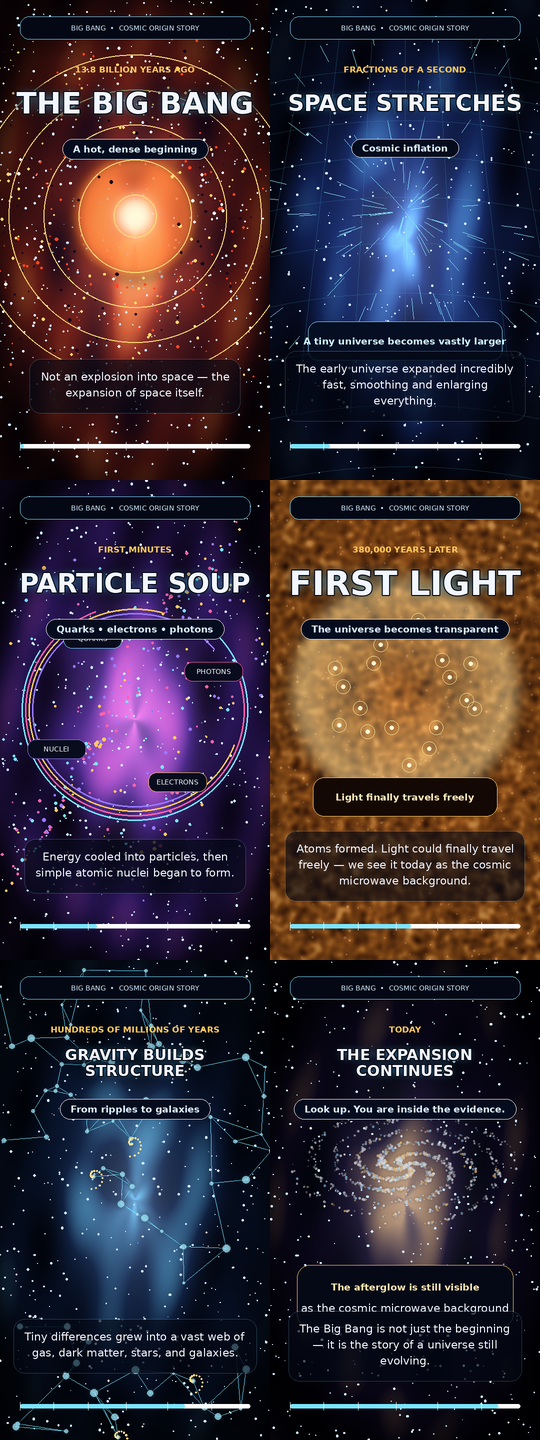

In [5]:
# ==========================
# Render storyboard preview
# ==========================
preview_times = [0.7, 7.2, 14.0, 22.0, 30.0, 38.0]
frames = [Image.fromarray(make_frame(int(t * FPS))) for t in preview_times]
thumb_w = W // 2
thumb_h = H // 2
contact = Image.new("RGB", (thumb_w * 2, thumb_h * 3), (0, 0, 0))
for idx, frame in enumerate(frames):
    thumb = frame.resize((thumb_w, thumb_h), Image.Resampling.LANCZOS)
    contact.paste(thumb, ((idx % 2) * thumb_w, (idx // 2) * thumb_h))
contact.save(STORYBOARD_NAME, quality=95)
print(f"Saved storyboard preview: {STORYBOARD_NAME}")
contact

In [6]:
# ==========================
# Render the full vertical video
# ==========================
# Tip: keep DRAFT_MODE=True for testing. Set DRAFT_MODE=False in the config cell for a sharper final export.
writer = imageio.get_writer(
    VIDEO_NAME,
    fps=FPS,
    codec="libx264",
    quality=8 if DRAFT_MODE else 9,
    pixelformat="yuv420p",
    macro_block_size=16,
)

for frame_idx in tqdm(range(NFRAMES), desc="Rendering Big Bang cinematic short"):
    writer.append_data(make_frame(frame_idx))
writer.close()

print(f"Saved video: {VIDEO_NAME}")
print(f"Duration: {VIDEO_SECONDS:.1f}s | FPS: {FPS} | Size: {W}x{H}")

Rendering Big Bang cinematic short:   0%|          | 0/840 [00:00<?, ?it/s]

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (540, 960) to (544, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved video: big_bang_cinematic_output/Big_Bang_Cinematic_Info_Shorts.mp4
Duration: 42.0s | FPS: 20 | Size: 540x960


In [ ]:
# Display video inside the notebook, if supported
from IPython.display import Video, display

display(Video(str(VIDEO_NAME), embed=True, html_attributes="controls autoplay loop"))

## Easy ways to customize

Edit only the `SCENES` list in the config cell to change text timing and captions. The visuals are tied to each scene's `kind`, so the video stays cinematic even if you rewrite the script.

For a stronger Shorts style, keep captions short and punchy. For a documentary style, make the captions longer and set `VIDEO_SECONDS` to 60.